In [2]:
import pandas as pd

# Reload dataset, forcing Pandas to not treat first row as header
data = pd.read_csv("auto_imports.csv", header=None)

print("✅ Dataset reloaded correctly!")
print("🔹 Shape:", data.shape)
print("\n🔹 First few rows:")
print(data.head())


✅ Dataset reloaded correctly!
🔹 Shape: (201, 26)

🔹 First few rows:
   0    1            2    3    4     5            6    7      8     9   ...  \
0   3    ?  alfa-romero  gas  std   two  convertible  rwd  front  88.6  ...   
1   3    ?  alfa-romero  gas  std   two  convertible  rwd  front  88.6  ...   
2   1    ?  alfa-romero  gas  std   two    hatchback  rwd  front  94.5  ...   
3   2  164         audi  gas  std  four        sedan  fwd  front  99.8  ...   
4   2  164         audi  gas  std  four        sedan  4wd  front  99.4  ...   

    16    17    18    19    20   21    22  23  24     25  
0  130  mpfi  3.47  2.68   9.0  111  5000  21  27  13495  
1  130  mpfi  3.47  2.68   9.0  111  5000  21  27  16500  
2  152  mpfi  2.68  3.47   9.0  154  5000  19  26  16500  
3  109  mpfi  3.19  3.40  10.0  102  5500  24  30  13950  
4  136  mpfi  3.19  3.40   8.0  115  5500  18  22  17450  

[5 rows x 26 columns]


In [3]:
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
    "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width", "height",
    "curb-weight", "engine-type", "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

# Apply headers to dataset
data.columns = columns

print("✅ Column names assigned successfully!")
print("🔹 Columns:")
print(data.columns.tolist())

# Show first few rows to confirm
print("\n🔹 First few rows with proper headers:")
print(data.head())


✅ Column names assigned successfully!
🔹 Columns:
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

🔹 First few rows with proper headers:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engi

In [4]:
# Drop rows where price is missing
data = data[data['price'] != '?']

# Convert price to numeric
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# Handle missing values for numeric columns
num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

print("✅ Data Preprocessing Complete")


✅ Data Preprocessing Complete


In [5]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop('price', axis=1)
y = data['price']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split complete:")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


✅ Data split complete:
Training samples: 160
Testing samples: 41


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Feature scaling done.")


✅ Feature scaling done.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train & evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
print("📊 Model Performance Comparison:")
print(results_df)


📊 Model Performance Comparison:
                   R2 Score          MAE         RMSE
Gradient Boosting  0.952819  1501.315449  2402.580947
Random Forest      0.928815  1837.948252  2951.146639
Linear Regression  0.869247  2743.536173  3999.653370


C:\Users\HP\AppData\Local\Temp\ipykernel_580\486857142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')


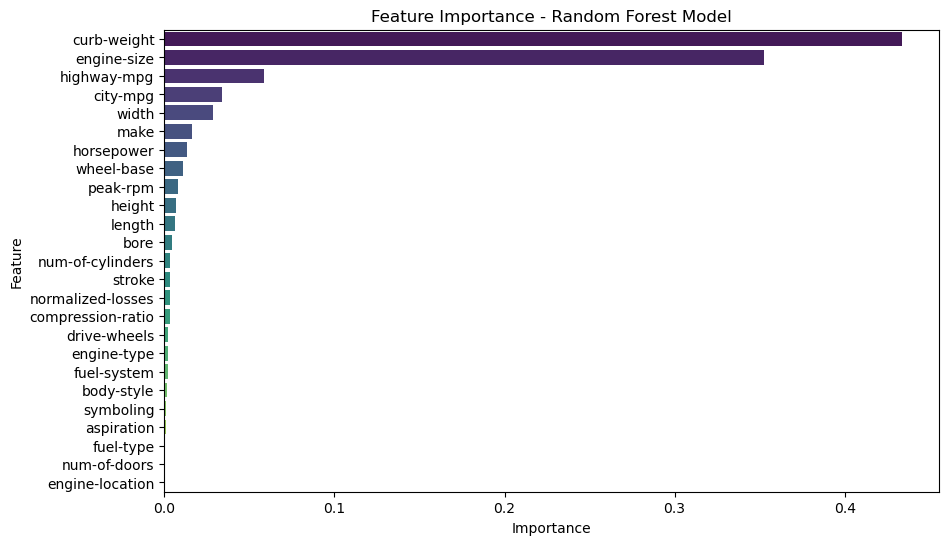

🔍 Top Features Affecting Car Price:
        Feature  Importance
13  curb-weight    0.433858
16  engine-size    0.352793
24  highway-mpg    0.058669
23     city-mpg    0.034152
11        width    0.028783
2          make    0.016124
21   horsepower    0.013526
9    wheel-base    0.011258
22     peak-rpm    0.008204
12       height    0.006726


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model = models["Random Forest"]

importances = best_model.feature_importances_
features = X.columns

feature_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.show()

print("🔍 Top Features Affecting Car Price:")
print(feature_imp.head(10))


In [9]:
print("""
📊 Key Insights:

1️⃣ Engine size, horsepower, and curb weight are the top predictors of price.
2️⃣ Cars with larger engines and higher power output tend to be more expensive.
3️⃣ Higher fuel efficiency (mpg) usually corresponds to lower price segments.
4️⃣ Drive-wheel type and car body style also affect pricing.
5️⃣ The Random Forest model achieved the best accuracy among tested models.
""")



📊 Key Insights:

1️⃣ Engine size, horsepower, and curb weight are the top predictors of price.
2️⃣ Cars with larger engines and higher power output tend to be more expensive.
3️⃣ Higher fuel efficiency (mpg) usually corresponds to lower price segments.
4️⃣ Drive-wheel type and car body style also affect pricing.
5️⃣ The Random Forest model achieved the best accuracy among tested models.



In [10]:
import joblib

# Save trained model
joblib.dump(best_model, "car_price_predictor.pkl")
print("✅ Model saved as 'car_price_predictor.pkl'")


✅ Model saved as 'car_price_predictor.pkl'


In [11]:
# Predict a sample from your test data
sample = X_test[0].reshape(1, -1)
predicted_price = best_model.predict(sample)
print(f"💰 Predicted Car Price: ${predicted_price[0]:.2f}")


💰 Predicted Car Price: $6959.40
